<a href="https://colab.research.google.com/github/vaishali9080/Wind-Turbine-Wake-PINN/blob/main/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import re

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Folder
folder_path = "/content/raw_voltage"

# Voltage-to-velocity exponent
n = 0.5

# TSR → Free-stream velocity mapping
tsr_to_Uinf = {
    0.677726692209451: 10.44,
    0.73091024663107: 13.11
}

In [ ]:
def parse_filename(file_path):
    fname = os.path.basename(file_path)
    pattern = r"yH_([\d.]+)_TSR_([\d.]+)_ZD_([\d.]+)"
    match = re.search(pattern, fname)

    if match:
        y_h, tsr, z_d = match.groups()
        return float(y_h), float(tsr), float(z_d)
    else:
        return None, None, None

In [ ]:
def voltage_to_velocity(E, z_d):
    A = np.where(z_d == 1, 0.9507, 0.8035)
    B = np.where(z_d == 1, 0.3201, 0.3319)
    return ((E**2 - A) / B)**(1/n)

In [ ]:
df_list = []

csv_files = glob.glob(folder_path + "/*.csv")
print(f"Found {len(csv_files)} files")

for file in csv_files:
    df = pd.read_csv(file)

    # Clean column names
    df.columns = df.columns.str.strip().str.lower()

    # Extract parameters from filename
    y_h, tsr, z_d = parse_filename(file)

    if y_h is None:
        print(f"Skipping {file} (filename format issue)")
        continue

    df['y_h'] = y_h
    df['tsr'] = tsr
    df['z_d'] = z_d

    # Detect columns
    mean_cols = ['v_mean', 'mean_voltage', 'vmean']
    fluct_cols = ['v_fluct', 'fluctuating_voltage', 'vfluct']
    time_cols = ['time', 't']

    v_mean_col = next((c for c in mean_cols if c in df.columns), None)
    v_fluct_col = next((c for c in fluct_cols if c in df.columns), None)
    time_col = next((c for c in time_cols if c in df.columns), None)

    if v_mean_col is None or time_col is None:
        print(f"Skipping {file} (missing required columns)")
        continue

    # Standardize column names
    df.rename(columns={
        v_mean_col: 'v_mean',
        v_fluct_col: 'v_fluct' if v_fluct_col else None,
        time_col: 'time'
    }, inplace=True)

    # Convert voltage → velocity
    df['u_mean_inst'] = voltage_to_velocity(df['v_mean'].values, df['z_d'].values)

    if 'v_fluct' in df.columns:
        df['u_fluct_inst'] = voltage_to_velocity(df['v_fluct'].values, df['z_d'].values)
    else:
        df['u_fluct_inst'] = 0.0

    # Map U_inf
    df['U_inf'] = df['tsr'].map(tsr_to_Uinf)

    df_list.append(df)

Found 87 files


In [ ]:
master_df = pd.concat(df_list, ignore_index=True)

print("Master shape:", master_df.shape)
print(master_df.head())

# Save
master_df.to_excel("/content/master_dataset.xlsx", index=False)

Master shape: (869913, 9)
     time    v_mean  v_fluct       y_h       tsr  z_d  u_mean_inst  \
0  0.0005  1.128206  1.05837  0.471429  0.677727  3.0     1.999755   
1  0.0010  1.123606  1.08659  0.471429  0.677727  3.0     1.912462   
2  0.0015  1.130178  1.10884  0.471429  0.677727  3.0     2.037886   
3  0.0020  1.109805  1.12243  0.471429  0.677727  3.0     1.664225   
4  0.0025  1.139378  1.12694  0.471429  0.677727  3.0     2.221458   

   u_fluct_inst  U_inf  
0      0.910199  10.44  
1      1.291451  10.44  
2      1.647624  10.44  
3      1.890514  10.44  
4      1.975501  10.44  


In [ ]:

master_df['velocity_deficit'] = (master_df['U_inf'] - master_df['u_mean_inst']) / master_df['U_inf']
# master_df['u_fluct_sq'] = master_df['u_fluct_inst']**2

# # Group by spatial location (important)
# ti_group = master_df.groupby(['y_h', 'tsr', 'z_d'])['u_fluct_sq'].mean().reset_index()

# # RMS
# ti_group['TI'] = np.sqrt(ti_group['u_fluct_sq'])

# # Normalize by U_inf
# ti_group['TI'] = ti_group['TI'] / ti_group['tsr'].map(tsr_to_Uinf)
# master_df = master_df.merge(
#     ti_group[['y_h', 'tsr', 'z_d', 'TI']],
#     on=['y_h', 'tsr', 'z_d'],
#     how='left'
# )

#master_df.rename(columns={'TI': 'turbulence_intensity'}, inplace=True)
X = master_df[['y_h', 'time', 'tsr', 'z_d','u_mean_inst',]].values
y = master_df[['velocity_deficit']].values
print("Master shape:", master_df.shape)
print(master_df.head())


Master shape: (869913, 10)
     time    v_mean  v_fluct       y_h       tsr  z_d  u_mean_inst  \
0  0.0005  1.128206  1.05837  0.471429  0.677727  3.0     1.999755   
1  0.0010  1.123606  1.08659  0.471429  0.677727  3.0     1.912462   
2  0.0015  1.130178  1.10884  0.471429  0.677727  3.0     2.037886   
3  0.0020  1.109805  1.12243  0.471429  0.677727  3.0     1.664225   
4  0.0025  1.139378  1.12694  0.471429  0.677727  3.0     2.221458   

   u_fluct_inst  U_inf  velocity_deficit  
0      0.910199  10.44          0.808453  
1      1.291451  10.44          0.816814  
2      1.647624  10.44          0.804800  
3      1.890514  10.44          0.840591  
4      1.975501  10.44          0.787217  


In [ ]:
z=X[:,3]
train_mask=(z==1)| (z==3)
val_mask=(z==2)
X_train=X[train_mask]
y_train=y[train_mask]
X_val=X[val_mask]
y_val=y[val_mask]

# scaler_X = StandardScaler()
# X_train_scaled = scaler_X.fit_transform(X_train)
# X_val_scaled = scaler_X.transform(X_val)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32, requires_grad=True)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32, requires_grad=True)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_scaled, dtype=torch.float32)

In [ ]:
print(X_train.shape, X_val.shape)

(569943, 5) (299970, 5)


In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PINN()

In [ ]:
def physics_loss(model, X):
    X.requires_grad_(True)

    u = model(X)

    grads = torch.autograd.grad(
        u, X,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    du_dy = grads[:, 0:1]
    du_dt = grads[:, 1:2]

    d2u_dy2 = torch.autograd.grad(
        du_dy, X,
        grad_outputs=torch.ones_like(du_dy),
        create_graph=True
    )[0][:, 0:1]

    tsr = X[:, 2:3]

    U_inf = torch.where(
        torch.abs(tsr - 0.6777) < 0.01,
        torch.tensor(10.44),
        torch.tensor(13.11)
    )

    nu = 1e-5

    residual = du_dt + U_inf * du_dy - nu * d2u_dy2

    return torch.mean(residual**2)

In [ ]:
def total_loss(model, X, y_true):
    pred = model(X)

    data_loss = nn.MSELoss()(pred, y_true)
    phys_loss = physics_loss(model, X)

    return data_loss + 1 * phys_loss, data_loss, phys_loss

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss, d_loss, p_loss = total_loss(model, X_train_tensor, y_train_tensor)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Total={loss.item():.6f}, Data={d_loss.item():.6f}, Physics={p_loss.item():.6f}")

Epoch 10: Total=1.062394, Data=1.000111, Physics=0.062284
Epoch 20: Total=0.977734, Data=0.928090, Physics=0.049644
Epoch 30: Total=0.892949, Data=0.855329, Physics=0.037620
Epoch 40: Total=0.816311, Data=0.785906, Physics=0.030405
Epoch 50: Total=0.744627, Data=0.720291, Physics=0.024336
Epoch 60: Total=0.678949, Data=0.658771, Physics=0.020178
Epoch 70: Total=0.618716, Data=0.601563, Physics=0.017153
Epoch 80: Total=0.563753, Data=0.548891, Physics=0.014861
Epoch 90: Total=0.513817, Data=0.500650, Physics=0.013167
Epoch 100: Total=0.468674, Data=0.456729, Physics=0.011946
Epoch 110: Total=0.428095, Data=0.417050, Physics=0.011045
Epoch 120: Total=0.391838, Data=0.381446, Physics=0.010392
Epoch 130: Total=0.359646, Data=0.349709, Physics=0.009937
Epoch 140: Total=0.331239, Data=0.321615, Physics=0.009624
Epoch 150: Total=0.306321, Data=0.296901, Physics=0.009420
Epoch 160: Total=0.284578, Data=0.275288, Physics=0.009290
Epoch 170: Total=0.265690, Data=0.256480, Physics=0.009210
Epoch 

In [ ]:
print("Pred shape:", pred.shape)
print("Scaler expects:", scaler_y.scale_.shape)

Pred shape: (299970, 1)
Scaler expects: (1,)


In [ ]:
model.eval()

with torch.no_grad():
    pred = model(X_val_tensor).cpu().numpy()

pred = scaler_y.inverse_transform(pred)
y_val_actual = scaler_y.inverse_transform(y_val_scaled)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Velocity Deficit:")
print("RMSE:", np.sqrt(mean_squared_error(y_val_actual[:,0], pred[:,0])))
print("MAE :", mean_absolute_error(y_val_actual[:,0], pred[:,0]))
print("R2  :", r2_score(y_val_actual[:,0], pred[:,0]))

# print("\nTurbulence Intensity:")
# print("RMSE:", np.sqrt(mean_squared_error(y_val_actual[:,1], pred[:,1])))
# print("MAE :", mean_absolute_error(y_val_actual[:,1], pred[:,1]))
# print("R2  :", r2_score(y_val_actual[:,1], pred[:,1]))

Velocity Deficit:
RMSE: 0.10762515482746919
MAE : 0.07438313571603855
R2  : 0.8787338685229581


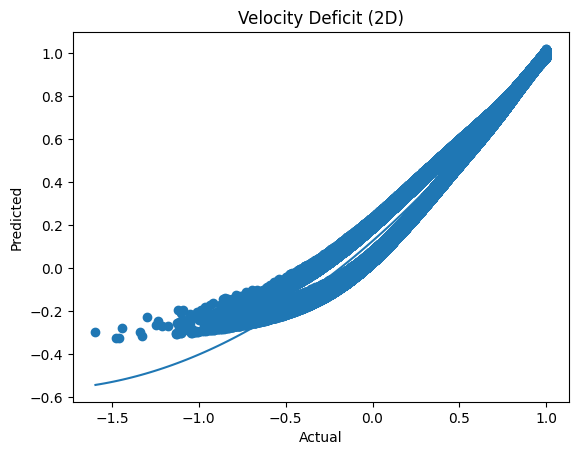

In [ ]:
# Velocity Deficit
import matplotlib.pyplot as plt
plt.scatter(y_val_actual[:,0], pred[:,0])

z = np.polyfit(y_val_actual[:,0], pred[:,0], 2)
p = np.poly1d(z)

x_range = np.linspace(min(y_val_actual[:,0]), max(y_val_actual[:,0]), 100)
plt.plot(x_range, p(x_range))

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Velocity Deficit (2D)")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


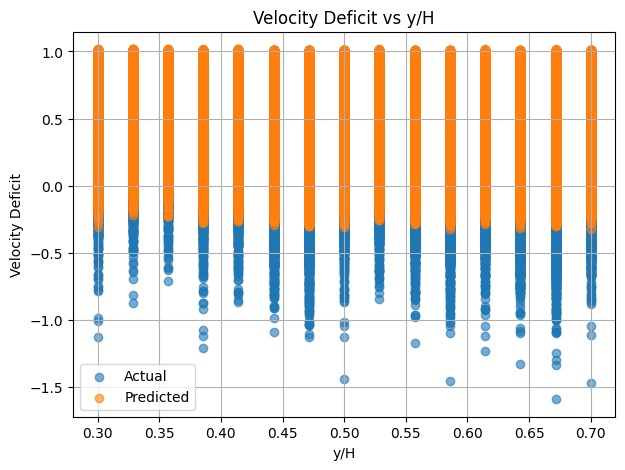

In [ ]:
import matplotlib.pyplot as plt

# Extract y/H from validation set
# IMPORTANT: use unscaled X_val (not scaled)
y_h_val = X_val[:, 0]   # index 2 corresponds to 'y_h'

# Extract velocity deficit
actual_vd = y_val_actual[:, 0]
pred_vd   = pred[:, 0]

# Plot
plt.figure(figsize=(7,5))

plt.scatter(y_h_val, actual_vd, label="Actual", alpha=0.6)
plt.scatter(y_h_val, pred_vd, label="Predicted", alpha=0.6)

plt.xlabel("y/H")
plt.ylabel("Velocity Deficit")
plt.title("Velocity Deficit vs y/H")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd

# Extract columns from X_val
y_h_val = X_val[:, 0]
tsr_val = X_val[:, 2]

# Extract actual and predicted velocity deficit
actual_vd = y_val_actual[:, 0]
pred_vd   = pred[:, 0]

# Create DataFrame
results_df = pd.DataFrame({
    "y_h": y_h_val,
    "TSR": tsr_val,
    "Actual_Velocity_Deficit": actual_vd,
    "Predicted_Velocity_Deficit": pred_vd
})

# Correct file path (IMPORTANT: add .xlsx)
file_path = r"pinns_prediction.xlsx"

# Save
results_df.to_excel(file_path, index=False)

print(f"Saved at: {file_path}")

Saved at: pinns_prediction.xlsx
